In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import robust_scale,minmax_scale
from sklearn.model_selection import KFold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2, L1, L2
from tensorflow.keras.optimizers import Adam

2023-11-08 19:37:52.836173: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = pd.read_csv("./../Data_Demo/filtered_input_train_lnc_features.csv", header=None)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,682,683,684,685,686,687,688,689,690,691
0,23,2763,1.0,825.0,52.0,25.0,-116090.0,18.0,0.0,4.0,...,0.001448,0.003619,0.007962,0.004343,0.013029,0.005791,0.005791,0.003619,0.006515,0.003619
1,23,1127,1.0,308.0,23.0,9.0,-33410.0,3.0,1.0,3.0,...,0.001775,0.005324,0.004437,0.007098,0.002662,0.000887,0.001775,0.001775,0.005324,0.001775
2,23,1081,1.0,295.0,21.0,11.0,-33570.0,3.0,0.0,3.0,...,0.003700,0.006475,0.004625,0.005550,0.001850,0.000925,0.003700,0.001850,0.002775,0.001850
3,23,1202,1.0,325.0,27.0,14.0,-37340.0,3.0,0.0,2.0,...,0.004160,0.005824,0.004992,0.004992,0.001664,0.001664,0.004160,0.002496,0.002496,0.003328
4,23,1085,1.0,292.0,24.0,11.0,-33610.0,3.0,0.0,2.0,...,0.003687,0.006452,0.004608,0.005530,0.001843,0.000922,0.003687,0.001843,0.002765,0.001843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,23,873,1.0,263.0,19.0,7.0,-28490.0,-1.0,-1.0,-1.0,...,0.003436,0.008018,0.006873,0.004582,0.004582,0.003436,0.006873,0.006873,0.005727,0.008018
886,23,473,1.0,126.0,13.0,2.0,-16200.0,-1.0,-1.0,-1.0,...,0.004228,0.006342,0.002114,0.006342,0.012685,0.008457,0.004228,0.000000,0.006342,0.006342
887,23,3201,1.0,917.0,57.0,25.0,-95510.0,13.0,0.0,3.0,...,0.003124,0.003436,0.003436,0.005623,0.003436,0.001250,0.005936,0.002187,0.001874,0.001874
888,23,8797,1.0,2702.0,139.0,59.0,-274977.0,13.0,1.0,9.0,...,0.002046,0.003865,0.002956,0.003069,0.002842,0.001023,0.004320,0.003410,0.001705,0.002842


In [4]:
labels = [1] * 528 + [0] * 362
labels = pd.DataFrame(labels)

In [5]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.25, stratify=labels, random_state=42)
dim = len(train_data.columns)

In [6]:
k =  5
kf = KFold(n_splits=k,shuffle=True,random_state=42)
histories = []
scores = []

In [12]:
def get_model():
    model = Sequential()
    model.add(BatchNormalization(input_shape = (dim,)))
    model.add(Dense(150,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(75,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(20,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(1,activation = 'sigmoid', bias_initializer = 'zeros', kernel_initializer = 'glorot_normal'))
    return model

Epoch 1/200
134/134 [==============================] - 2s 6ms/step - loss: 1.6260 - accuracy: 0.5891 - val_loss: 1.6044 - val_accuracy: 0.5597
Epoch 2/200
134/134 [==============================] - 1s 7ms/step - loss: 1.5241 - accuracy: 0.6098 - val_loss: 1.4509 - val_accuracy: 0.5746
Epoch 3/200
134/134 [==============================] - 1s 5ms/step - loss: 1.4314 - accuracy: 0.6266 - val_loss: 1.3713 - val_accuracy: 0.8284
Epoch 4/200
134/134 [==============================] - 1s 7ms/step - loss: 1.3816 - accuracy: 0.6548 - val_loss: 1.3045 - val_accuracy: 0.7985
Epoch 5/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3272 - accuracy: 0.6867 - val_loss: 1.2521 - val_accuracy: 0.7836
Epoch 6/200
134/134 [==============================] - 0s 4ms/step - loss: 1.2727 - accuracy: 0.7092 - val_loss: 1.2029 - val_accuracy: 0.7687
Epoch 7/200
134/134 [==============================] - 0s 4ms/step - loss: 1.2522 - accuracy: 0.7280 - val_loss: 1.1654 - val_accuracy: 0.7761

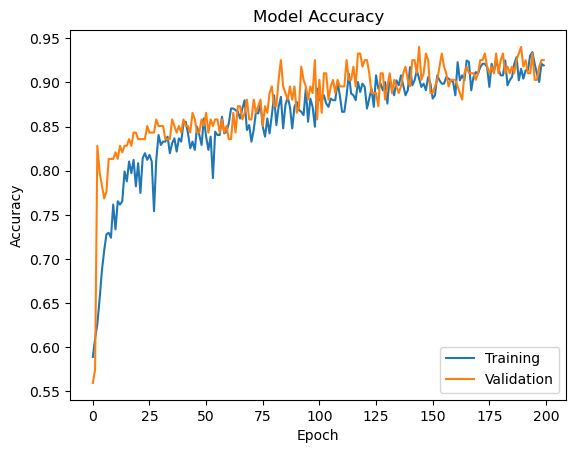

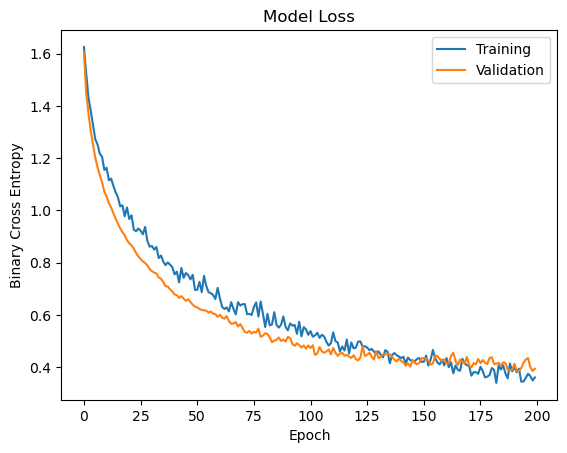

Epoch 1/200
134/134 [==============================] - 1s 6ms/step - loss: 1.6130 - accuracy: 0.5741 - val_loss: 1.5229 - val_accuracy: 0.5821
Epoch 2/200
134/134 [==============================] - 1s 5ms/step - loss: 1.5107 - accuracy: 0.5647 - val_loss: 1.4373 - val_accuracy: 0.8657
Epoch 3/200
134/134 [==============================] - 1s 4ms/step - loss: 1.4045 - accuracy: 0.6266 - val_loss: 1.3673 - val_accuracy: 0.8433
Epoch 4/200
134/134 [==============================] - 1s 5ms/step - loss: 1.3613 - accuracy: 0.6417 - val_loss: 1.3015 - val_accuracy: 0.8358
Epoch 5/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3112 - accuracy: 0.6548 - val_loss: 1.2384 - val_accuracy: 0.8507
Epoch 6/200
134/134 [==============================] - 1s 5ms/step - loss: 1.2580 - accuracy: 0.6886 - val_loss: 1.1854 - val_accuracy: 0.8507
Epoch 7/200
134/134 [==============================] - 1s 5ms/step - loss: 1.2254 - accuracy: 0.7111 - val_loss: 1.1508 - val_accuracy: 0.8582

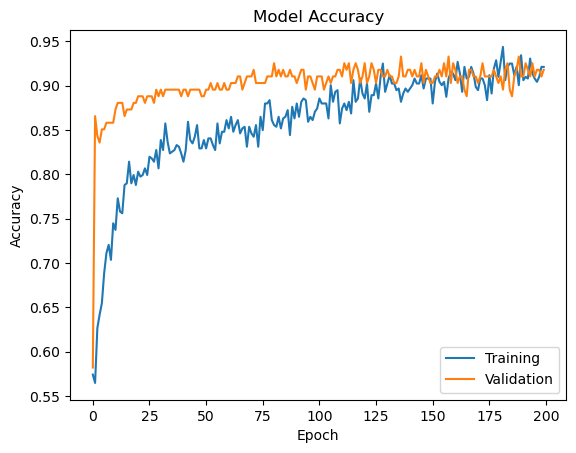

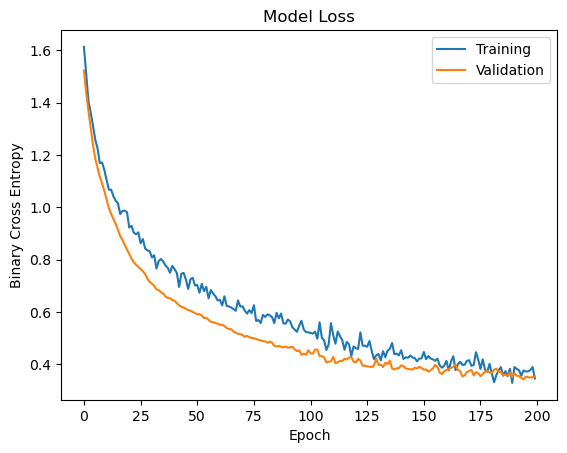

Epoch 1/200
134/134 [==============================] - 1s 5ms/step - loss: 1.6193 - accuracy: 0.5337 - val_loss: 1.5377 - val_accuracy: 0.5489
Epoch 2/200
134/134 [==============================] - 1s 5ms/step - loss: 1.5247 - accuracy: 0.5824 - val_loss: 1.4399 - val_accuracy: 0.8346
Epoch 3/200
134/134 [==============================] - 1s 5ms/step - loss: 1.4305 - accuracy: 0.6142 - val_loss: 1.3742 - val_accuracy: 0.8346
Epoch 4/200
134/134 [==============================] - 1s 5ms/step - loss: 1.3760 - accuracy: 0.6592 - val_loss: 1.3142 - val_accuracy: 0.8421
Epoch 5/200
134/134 [==============================] - 1s 5ms/step - loss: 1.3336 - accuracy: 0.6704 - val_loss: 1.2629 - val_accuracy: 0.8496
Epoch 6/200
134/134 [==============================] - 1s 5ms/step - loss: 1.2813 - accuracy: 0.6966 - val_loss: 1.2239 - val_accuracy: 0.8271
Epoch 7/200
134/134 [==============================] - 1s 5ms/step - loss: 1.2324 - accuracy: 0.7528 - val_loss: 1.1817 - val_accuracy: 0.8496

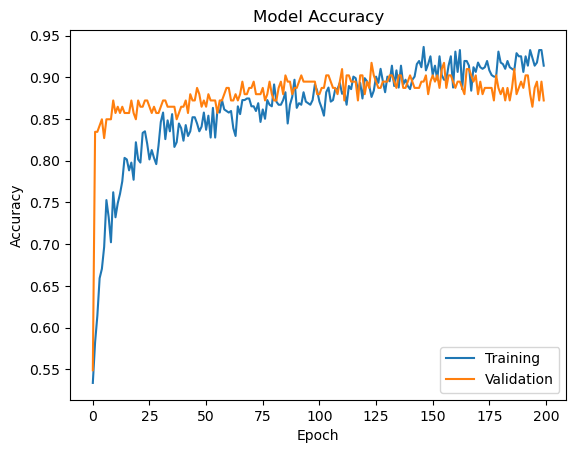

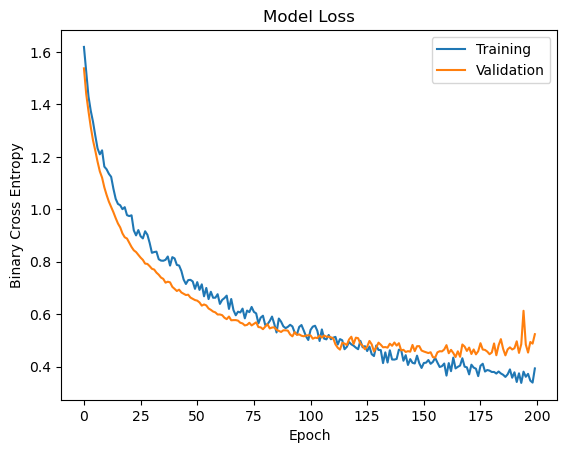

Epoch 1/200
134/134 [==============================] - 2s 6ms/step - loss: 1.6441 - accuracy: 0.5300 - val_loss: 1.5542 - val_accuracy: 0.6316
Epoch 2/200
134/134 [==============================] - 1s 4ms/step - loss: 1.5323 - accuracy: 0.5712 - val_loss: 1.4875 - val_accuracy: 0.6165
Epoch 3/200
134/134 [==============================] - 1s 4ms/step - loss: 1.4470 - accuracy: 0.5955 - val_loss: 1.3929 - val_accuracy: 0.8045
Epoch 4/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3887 - accuracy: 0.6442 - val_loss: 1.3122 - val_accuracy: 0.8271
Epoch 5/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3468 - accuracy: 0.6498 - val_loss: 1.2430 - val_accuracy: 0.8496
Epoch 6/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3006 - accuracy: 0.6873 - val_loss: 1.1891 - val_accuracy: 0.8496
Epoch 7/200
134/134 [==============================] - 1s 4ms/step - loss: 1.2617 - accuracy: 0.6910 - val_loss: 1.1475 - val_accuracy: 0.8647

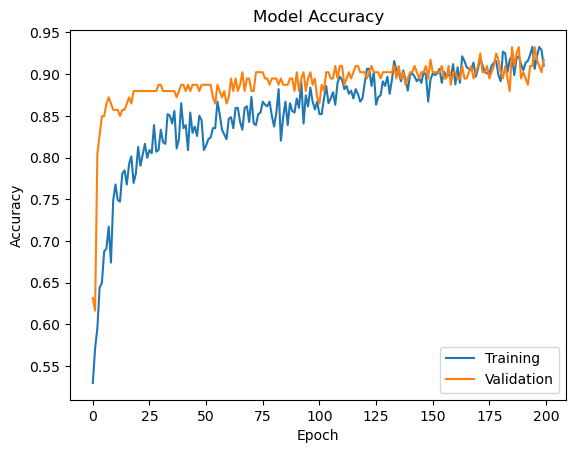

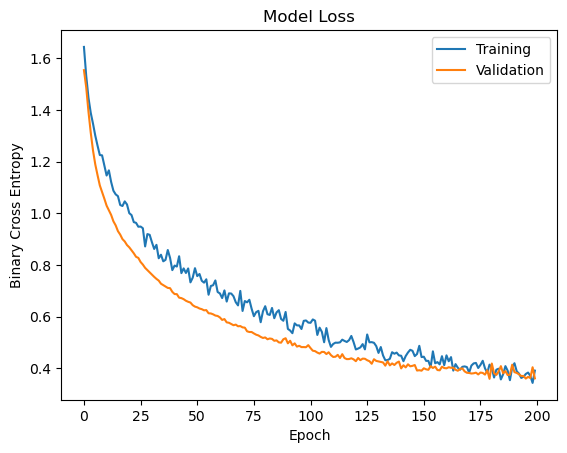

Epoch 1/200
134/134 [==============================] - 1s 5ms/step - loss: 1.6281 - accuracy: 0.5599 - val_loss: 1.5408 - val_accuracy: 0.6466
Epoch 2/200
134/134 [==============================] - 1s 4ms/step - loss: 1.5175 - accuracy: 0.6142 - val_loss: 1.4540 - val_accuracy: 0.9098
Epoch 3/200
134/134 [==============================] - 1s 4ms/step - loss: 1.4403 - accuracy: 0.6199 - val_loss: 1.3679 - val_accuracy: 0.8647
Epoch 4/200
134/134 [==============================] - 0s 3ms/step - loss: 1.3757 - accuracy: 0.6273 - val_loss: 1.2869 - val_accuracy: 0.8571
Epoch 5/200
134/134 [==============================] - 1s 4ms/step - loss: 1.3139 - accuracy: 0.7079 - val_loss: 1.2203 - val_accuracy: 0.8722
Epoch 6/200
134/134 [==============================] - 1s 5ms/step - loss: 1.2761 - accuracy: 0.6929 - val_loss: 1.1610 - val_accuracy: 0.8722
Epoch 7/200
134/134 [==============================] - 1s 4ms/step - loss: 1.2094 - accuracy: 0.7472 - val_loss: 1.1022 - val_accuracy: 0.8722

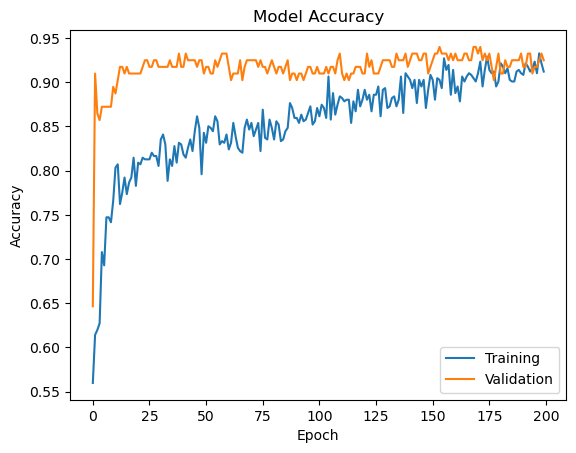

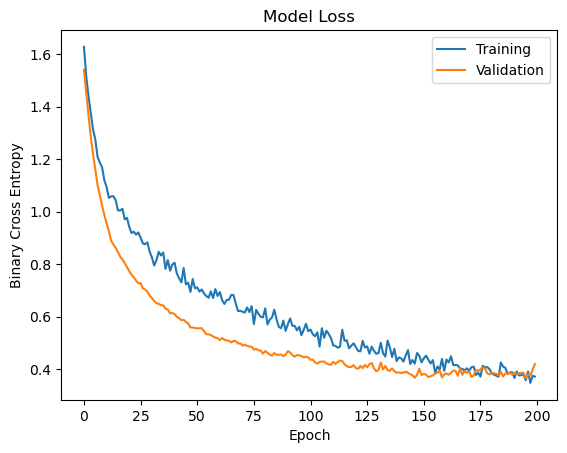

In [14]:
for train_index, test_index in kf.split(train_data):
    data_train, data_val = train_data.iloc[train_index], train_data.iloc[test_index]
    label_train, label_val = train_label.iloc[train_index], train_label.iloc[test_index]

    model = get_model()
    opt = Adam(0.0001)
    model.compile(optimizer=opt,loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(data_train,label_train,batch_size=4,epochs=200, validation_data = (data_val, label_val))
    
    score = model.evaluate(data_val, label_val)
    histories.append(history)
    scores.append(scores)

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Binary Cross Entropy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.show()